Measuring CPU usage with psutil.cpu_percent(interval=1)...
CPU usage measured: 21.0
CPU frequencies - Base: 0.0 MHz, Current: 2600.02 MHz, Max: 0.0 MHz
Estimated power consumption (W): 56.8
Estimated CPU Power Consumption (W): 56.8
CPU Utilization During Sampling (%): 21.0
Training set shape: (720855, 8)
Validation set shape: (240285, 8)
Test set shape: (240286, 8)
Training Time: 708.2133 seconds
Validation Prediction Time: 32.1959 seconds
Validation MSE: 0.04405024655495387
Validation R²: 0.9559489489511206
Test Prediction Time: 32.2879 seconds
Test MSE: 0.0431431091078827
Test R²: 0.9570383512291155
Total Energy Consumption (kJ): 43.88919377250671


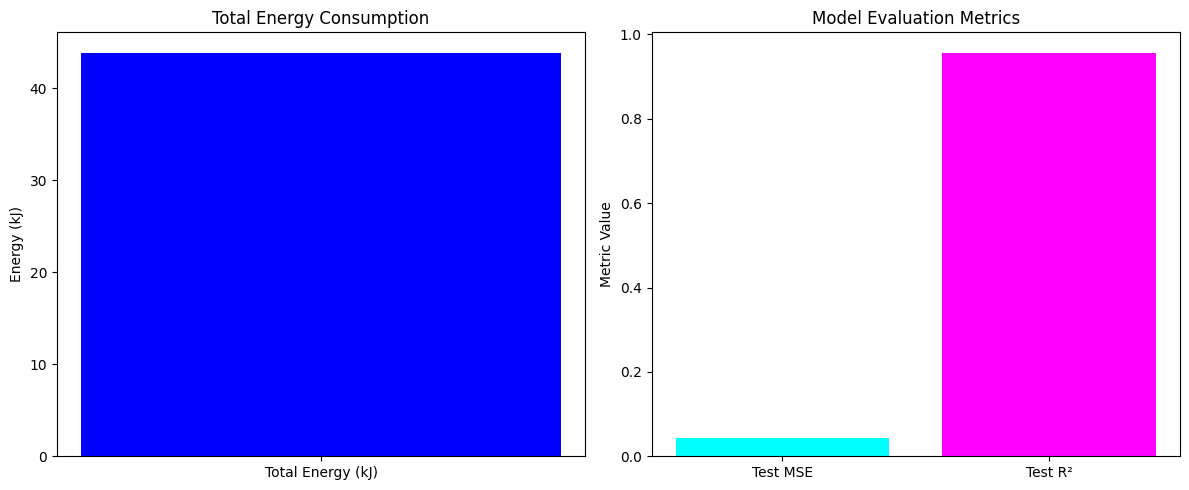

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ---- Added code for energy consumption measurement ----
import psutil

def get_dynamic_power_usage():
    print("Measuring CPU usage with psutil.cpu_percent(interval=1)...")
    cpu_usage = psutil.cpu_percent(interval=1)
    print("CPU usage measured:", cpu_usage)
    num_cores = psutil.cpu_count(logical=True)
    try:
        cpu_freq = psutil.cpu_freq()
    except Exception as e:
        print("Error reading CPU frequency:", e)
        cpu_freq = None
    if cpu_freq:
        base_freq = cpu_freq.min
        max_freq = cpu_freq.max
        current_freq = cpu_freq.current
    else:
        base_freq, max_freq, current_freq = 1000, 3000, 2000
        print("Using default CPU frequencies.")
    print(f"CPU frequencies - Base: {base_freq} MHz, Current: {current_freq} MHz, Max: {max_freq} MHz")
    
    base_power_per_core = 5    # Watts at base frequency
    max_power_per_core = 25    # Watts at max frequency
    freq_factor = (current_freq - base_freq) / (max_freq - base_freq) if max_freq > base_freq else 0.5
    estimated_power = num_cores * (base_power_per_core + freq_factor * (max_power_per_core - base_power_per_core) * (cpu_usage / 100))
    print("Estimated power consumption (W):", estimated_power)
    return estimated_power, cpu_usage

# Measure dynamic CPU power consumption before training
CPU_POWER_WATTS, cpu_usage_percent = get_dynamic_power_usage()
print("Estimated CPU Power Consumption (W):", CPU_POWER_WATTS)
print("CPU Utilization During Sampling (%):", cpu_usage_percent)
# ---- End of added energy consumption code ----

# 1. Load the preprocessed CSV file
data = pd.read_csv("../NeuralNetwork/Price_prediction_data.csv")

# 2. Separate features (X) and target variable (y)
X = data.drop(columns=["Price"])
y = data["Price"]

# 3. Split the dataset:
#    First: 60% training, 40% temporary set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

#    Second: split the temporary set into 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Print shapes to verify splits
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

# 4. Initialize the RandomForestRegressor with best parameters
rf_model = RandomForestRegressor(
    n_estimators=300,  # number of trees
    max_depth=20,      # maximum depth of each tree
    random_state=42
)

# 5. Train the model on the training set
start_train = time.time()
rf_model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training Time: {train_time:.4f} seconds")

# 6. Validate the model on the validation set
start_pred_val = time.time()
y_val_pred = rf_model.predict(X_val)
val_pred_time = time.time() - start_pred_val
print(f"Validation Prediction Time: {val_pred_time:.4f} seconds")

val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)
print("Validation MSE:", val_mse)
print("Validation R²:", val_r2)

# 7. Evaluate on the test set using the best model
start_pred_test = time.time()
y_test_pred = rf_model.predict(X_test)
test_pred_time = time.time() - start_pred_test
print(f"Test Prediction Time: {test_pred_time:.4f} seconds")

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("Test MSE:", test_mse)
print("Test R²:", test_r2)

# ---- Added energy consumption and visualization ----
# Compute total energy consumption in kilojoules for the whole algorithm (training + both predictions)
total_time = train_time + val_pred_time + test_pred_time
total_energy_kj = (CPU_POWER_WATTS * total_time) / 1000
print("Total Energy Consumption (kJ):", total_energy_kj)

# ----- Visualization -----
plt.figure(figsize=(12, 5))

# Subplot 1: Total Energy Consumption
plt.subplot(1, 2, 1)
plt.bar(['Total Energy (kJ)'], [total_energy_kj], color='blue')
plt.ylabel('Energy (kJ)')
plt.title('Total Energy Consumption')

# Subplot 2: Model Evaluation Metrics (Test set)
plt.subplot(1, 2, 2)
eval_metrics = [test_mse, test_r2]
eval_labels = ['Test MSE', 'Test R²']
plt.bar(eval_labels, eval_metrics, color=['cyan', 'magenta'])
plt.ylabel('Metric Value')
plt.title('Model Evaluation Metrics')

plt.tight_layout()
plt.show()